# Canada Vapes Sales Growth Analysis

## tl;dr

The customer file contains approximately **$20.73M recorded lifetime spend**, **165,358 orders**, and a **$125.39 weighted historical AOV**. Value is highly concentrated: the top 20% of customers contribute about 80% of lifetime spend. Protect repeat and high-value accounts first. A formal time-series sales forecast is not possible from this snapshot because it has no order dates.

## Context & methods

This notebook analyzes customer lifetime sales concentration, order economics, regional performance and illustrative next-order planning scenarios. It does not treat signup or last-active dates as transaction dates.

### 1. Setup and locate the analysis-ready file

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

COLORS = {
    "blue": "#35648F",
    "gold": "#C89B32",
    "orange": "#CC6B3D",
    "olive": "#7F8C55",
    "ink": "#2F3742",
    "grey": "#AAB4BF",
    "light": "#E7ECF1",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "text.color": COLORS["ink"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#D7DCE1",
    "grid.alpha": 0.75,
    "grid.linewidth": 0.8,
})

def find_data_file() -> Path:
    candidates = []
    configured = os.environ.get("CANADA_VAPES_ANALYSIS_FILE")
    if configured:
        candidates.append(Path(configured))
    candidates.extend([
        Path.cwd() / "CanadaVapes_analysis_ready.csv",
        Path.cwd() / "upload" / "CanadaVapes_analysis_ready.csv",
        Path("C:/Users/tooko/Downloads/canadavape/CanadaVapes_analysis_ready.csv"),
        Path("C:/Users/tooko/Downloads/canada vape/CanadaVapes_analysis_ready.csv"),
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "CanadaVapes_analysis_ready.csv was not found. Checked:\n" + checked
    )

DATA_FILE = find_data_file()
BASE_OUTPUT_FOLDER = DATA_FILE.parent / "CanadaVapes_strategic_outputs"
BASE_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

def money(value: float) -> str:
    return f"${value:,.0f}"

def percent(value: float) -> str:
    return f"{value:.1%}"

def finish_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

print("Analysis-ready data:", DATA_FILE)
print("Output folder:", BASE_OUTPUT_FOLDER)

Analysis-ready data: /workspace/scratch/392f36e0de90/upload/CanadaVapes_analysis_ready.csv
Output folder: /workspace/scratch/392f36e0de90/upload/CanadaVapes_strategic_outputs


### 2. Load and validate customer data

In [2]:
required_columns = {
    "customer_record_id", "last_active", "sign_up", "orders", "total_spend",
    "aov", "city", "region", "days_since_last_active",
    "customer_tenure_days", "record_quality_status", "data_quality_issue",
}

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
    parse_dates=["last_active", "sign_up"],
)

missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError("Required columns are missing: " + ", ".join(missing_columns))

for column in ["orders", "total_spend", "aov", "days_since_last_active", "customer_tenure_days"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df["customer_record_id"].duplicated().any():
    raise ValueError("customer_record_id is not unique.")
if df[["orders", "total_spend", "aov", "days_since_last_active"]].isna().any().any():
    raise ValueError("Core analysis fields contain missing or invalid numbers.")
if (df[["orders", "total_spend", "aov"]].lt(0)).any().any():
    raise ValueError("The analysis-ready file still contains negative core values.")

snapshot_date = df["last_active"].max().normalize()
df["is_repeat_customer"] = df["orders"].ge(2)
df["is_active_90d"] = df["days_since_last_active"].le(90)

print(f"Rows loaded: {len(df):,}")
print(f"Snapshot date: {snapshot_date.date()}")
display(df[[
    "customer_record_id", "last_active", "orders", "total_spend", "aov",
    "city", "region", "days_since_last_active"
]].head())

Rows loaded: 30,803
Snapshot date: 2026-07-08
customer_record_id         last_active  orders  total_spend    aov          city region  days_since_last_active
         CV-000001 2026-07-08 15:31:03      11     1,140.69 103.70      Neuville     QC                       0
         CV-000002 2026-07-08 15:29:52      54     8,902.99 164.87 Niagara Falls     ON                       0
         CV-000003 2026-07-08 15:28:42      18     2,713.19 150.73       Glencoe     ON                       0
         CV-000004 2026-07-08 15:28:26       2       180.64  90.32         Laval     QC                       0
         CV-000005 2026-07-08 15:26:59      49     6,284.21 128.25   Port Medway     NS                       0


### 3. Calculate sales KPIs and concentration

In [3]:
SALES_FOLDER = BASE_OUTPUT_FOLDER / "sales"
SALES_FOLDER.mkdir(parents=True, exist_ok=True)

total_customers = len(df)
total_orders = int(df["orders"].sum())
total_lifetime_spend = float(df["total_spend"].sum())
weighted_aov = total_lifetime_spend / total_orders
repeat_rate = float(df["is_repeat_customer"].mean())

ranked_customers = df.sort_values("total_spend", ascending=False).reset_index(drop=True).copy()
ranked_customers["customer_rank"] = np.arange(1, len(ranked_customers) + 1)
ranked_customers["cumulative_spend_share"] = ranked_customers["total_spend"].cumsum() / total_lifetime_spend
top_20_count = int(np.ceil(total_customers * 0.20))
top_20_spend_share = float(ranked_customers.head(top_20_count)["total_spend"].sum() / total_lifetime_spend)
pareto_customer_count = int(ranked_customers.loc[ranked_customers["cumulative_spend_share"].ge(0.80), "customer_rank"].iloc[0])

sales_kpis = pd.DataFrame({
    "metric": ["Customers", "Recorded lifetime spend", "Orders", "Weighted historical AOV", "Repeat-customer rate", "Top 20% spend share"],
    "value": [total_customers, total_lifetime_spend, total_orders, weighted_aov, repeat_rate, top_20_spend_share],
    "display": [f"{total_customers:,}", money(total_lifetime_spend), f"{total_orders:,}", f"${weighted_aov:,.2f}", percent(repeat_rate), percent(top_20_spend_share)],
})
sales_kpis.to_csv(SALES_FOLDER / "sales_kpi_summary.csv", index=False, encoding="utf-8-sig")
ranked_customers.head(top_20_count).to_csv(SALES_FOLDER / "top_20_percent_customer_accounts.csv", index=False, encoding="utf-8-sig")
display(sales_kpis[["metric", "display"]])

                 metric     display
              Customers      30,803
Recorded lifetime spend $20,734,892
                 Orders     165,358
Weighted historical AOV     $125.39
   Repeat-customer rate       53.0%
    Top 20% spend share       79.9%


### 4. Visualize customer sales concentration

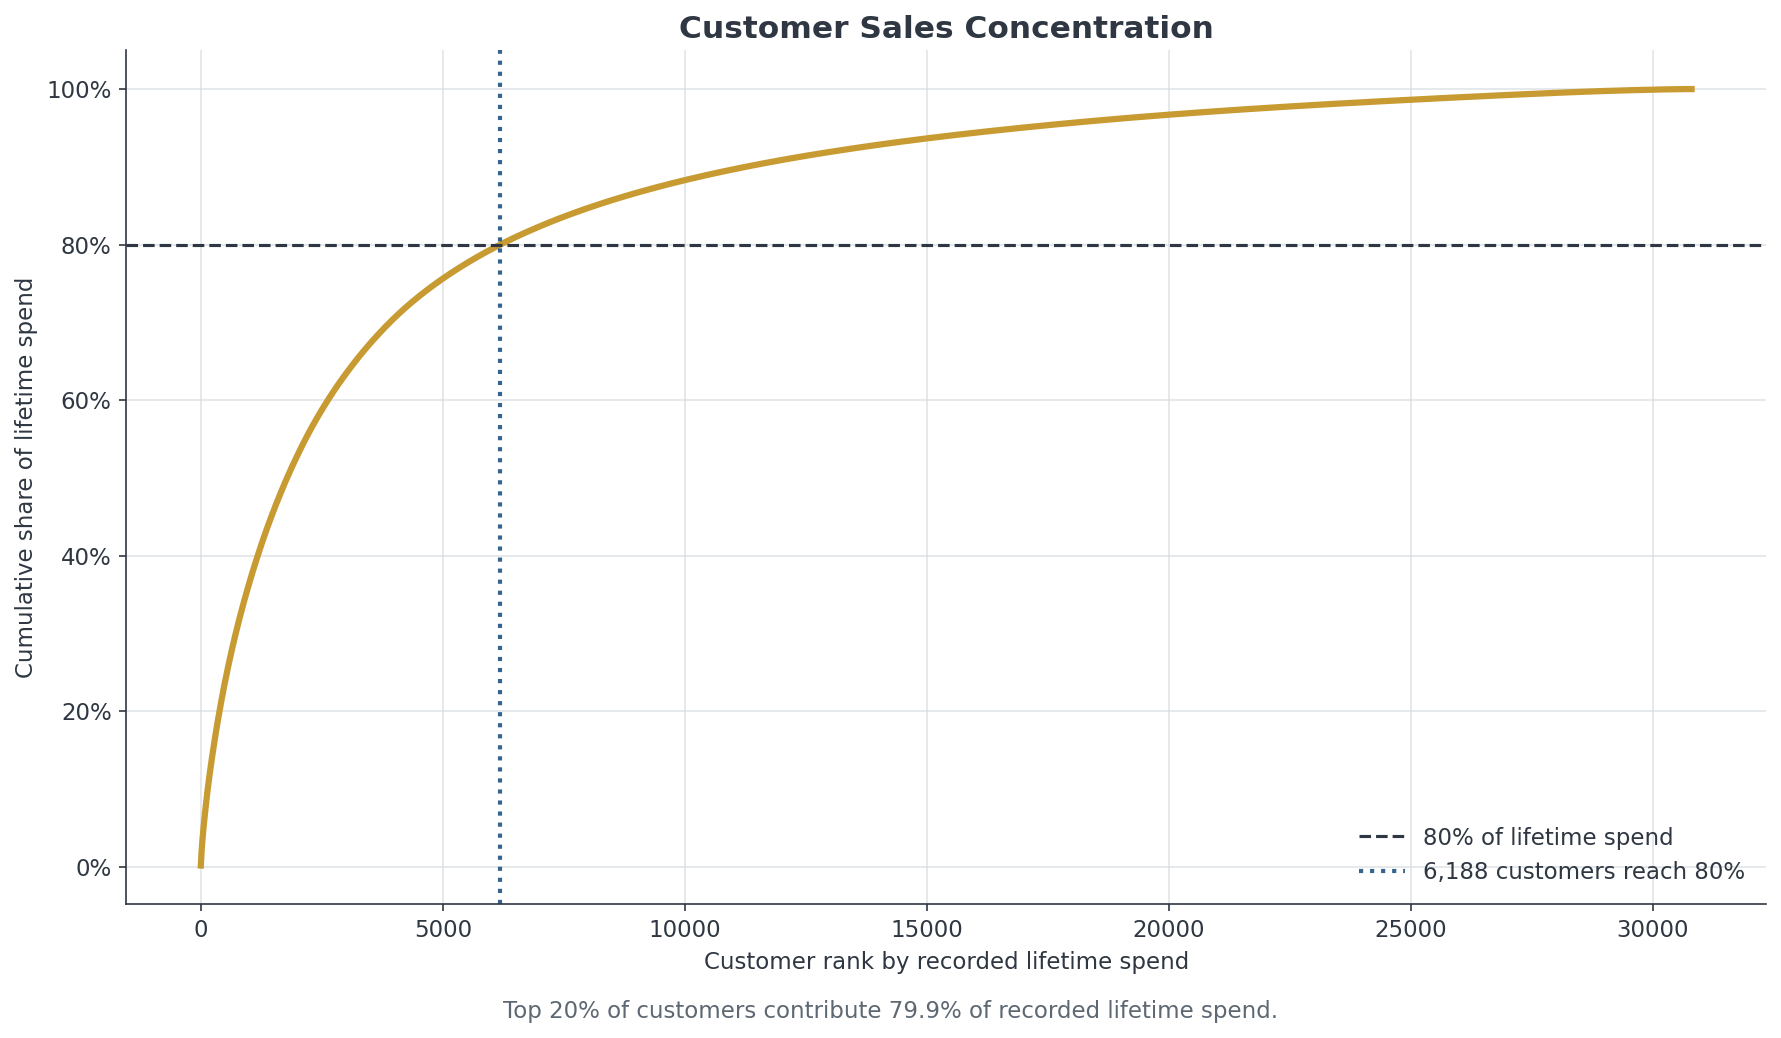

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(ranked_customers["customer_rank"], ranked_customers["cumulative_spend_share"], color=COLORS["gold"], linewidth=3)
ax.axhline(0.80, color=COLORS["ink"], linestyle="--", linewidth=1.5, label="80% of lifetime spend")
ax.axvline(pareto_customer_count, color=COLORS["blue"], linestyle=":", linewidth=2, label=f"{pareto_customer_count:,} customers reach 80%")
ax.set_title("Customer Sales Concentration")
ax.set_xlabel("Customer rank by recorded lifetime spend")
ax.set_ylabel("Cumulative share of lifetime spend")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, loc="lower right")
finish_axis(ax)
fig.text(0.5, 0.02, f"Top 20% of customers contribute {top_20_spend_share:.1%} of recorded lifetime spend.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = SALES_FOLDER / "01_customer_sales_pareto.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 5. Compare one-time and repeat-customer economics

In [5]:
repeat_summary = (
    df.groupby("is_repeat_customer", as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        lifetime_spend=("total_spend", "sum"),
        average_lifetime_spend=("total_spend", "mean"),
        median_aov=("aov", "median"),
        average_orders=("orders", "mean"),
    )
)
repeat_summary["customer_type"] = repeat_summary["is_repeat_customer"].map({False: "One-time", True: "Repeat"})
repeat_summary["customer_share"] = repeat_summary["customers"] / total_customers
repeat_summary["spend_share"] = repeat_summary["lifetime_spend"] / total_lifetime_spend
repeat_summary.to_csv(SALES_FOLDER / "one_time_vs_repeat_economics.csv", index=False, encoding="utf-8-sig")
display(repeat_summary)

 is_repeat_customer  customers  lifetime_spend  average_lifetime_spend  median_aov  average_orders customer_type  customer_share  spend_share
              False      14474    1,280,542.47                   88.47       73.48            1.00      One-time            0.47         0.06
               True      16329   19,454,349.43                1,191.40       93.45            9.24        Repeat            0.53         0.94


### 6. Visualize the value of repeat purchasing

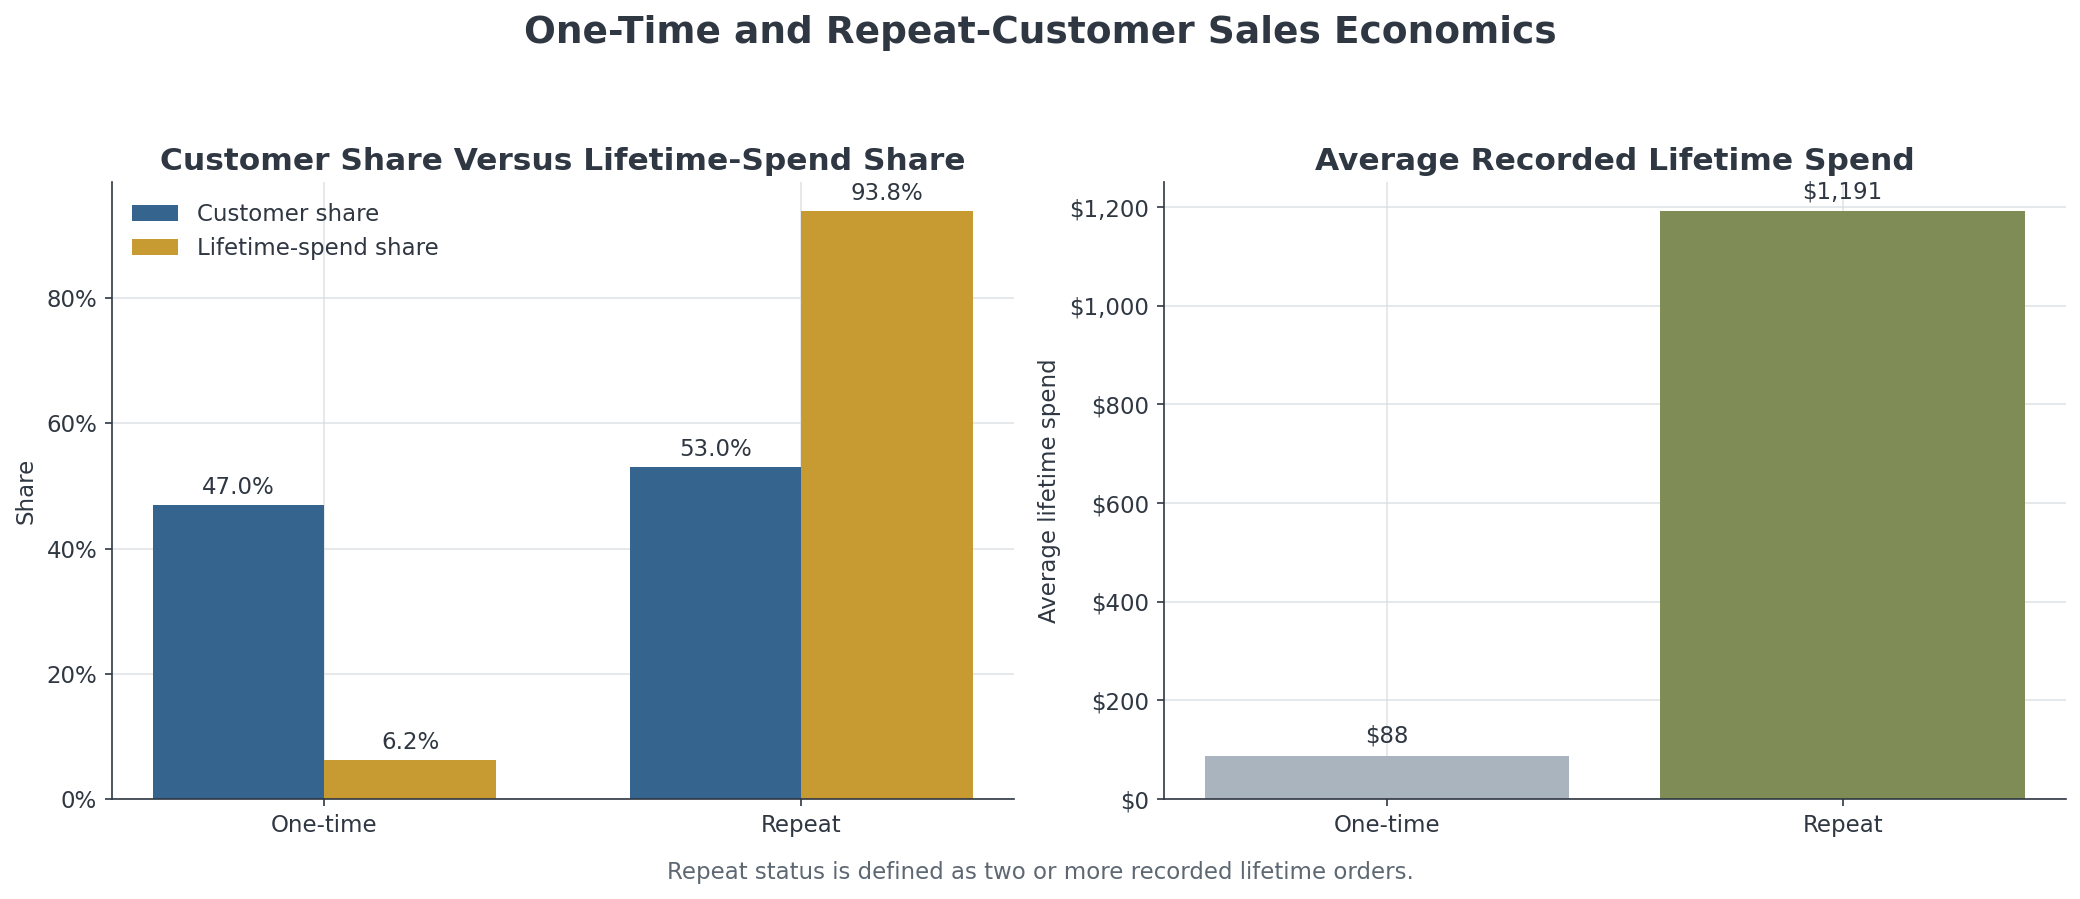

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(repeat_summary))
width = 0.36
axes[0].bar(x - width/2, repeat_summary["customer_share"], width, label="Customer share", color=COLORS["blue"])
axes[0].bar(x + width/2, repeat_summary["spend_share"], width, label="Lifetime-spend share", color=COLORS["gold"])
axes[0].set_xticks(x, repeat_summary["customer_type"])
axes[0].set_title("Customer Share Versus Lifetime-Spend Share")
axes[0].set_ylabel("Share")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(frameon=False)
for container in axes[0].containers:
    axes[0].bar_label(container, labels=[percent(v) for v in container.datavalues], padding=3)
finish_axis(axes[0])

bars = axes[1].bar(repeat_summary["customer_type"], repeat_summary["average_lifetime_spend"], color=[COLORS["grey"], COLORS["olive"]])
axes[1].set_title("Average Recorded Lifetime Spend")
axes[1].set_ylabel("Average lifetime spend")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].bar_label(bars, labels=[money(v) for v in repeat_summary["average_lifetime_spend"]], padding=4)
finish_axis(axes[1])

fig.suptitle("One-Time and Repeat-Customer Sales Economics", fontsize=18, fontweight="bold")
fig.text(0.5, 0.02, "Repeat status is defined as two or more recorded lifetime orders.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
CHART_FILE = SALES_FOLDER / "02_repeat_customer_economics.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 7. Compare regional scale and customer value

In [7]:
regional_sales = (
    df.dropna(subset=["region"])
    .groupby("region", as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        lifetime_spend=("total_spend", "sum"),
        average_lifetime_spend=("total_spend", "mean"),
        total_orders=("orders", "sum"),
        repeat_rate=("is_repeat_customer", "mean"),
        active_90d_rate=("is_active_90d", "mean"),
    )
)
regional_sales["weighted_aov"] = regional_sales["lifetime_spend"] / regional_sales["total_orders"]
regional_sales = regional_sales.sort_values("lifetime_spend", ascending=False)
regional_sales.to_csv(SALES_FOLDER / "regional_sales_summary.csv", index=False, encoding="utf-8-sig")
display(regional_sales)

region  customers  lifetime_spend  average_lifetime_spend  total_orders  repeat_rate  active_90d_rate  weighted_aov
    ON       9026    6,273,708.00                  695.07         51326         0.52             0.22        122.23
    QC       7914    5,359,950.08                  677.27         42742         0.55             0.26        125.40
    NS       3751    3,073,726.61                  819.44         25897         0.62             0.29        118.69
    BC       4037    2,268,979.54                  562.05         16847         0.48             0.21        134.68
    AB       2137    1,191,982.86                  557.78          8898         0.43             0.24        133.96
    NB       1318      922,717.83                  700.09          7563         0.57             0.30        122.00
    SK        564      436,737.08                  774.36          2898         0.54             0.25        150.70
    PE        594      435,651.22                  733.42          3436 

### 8. Visualize regional scale and value

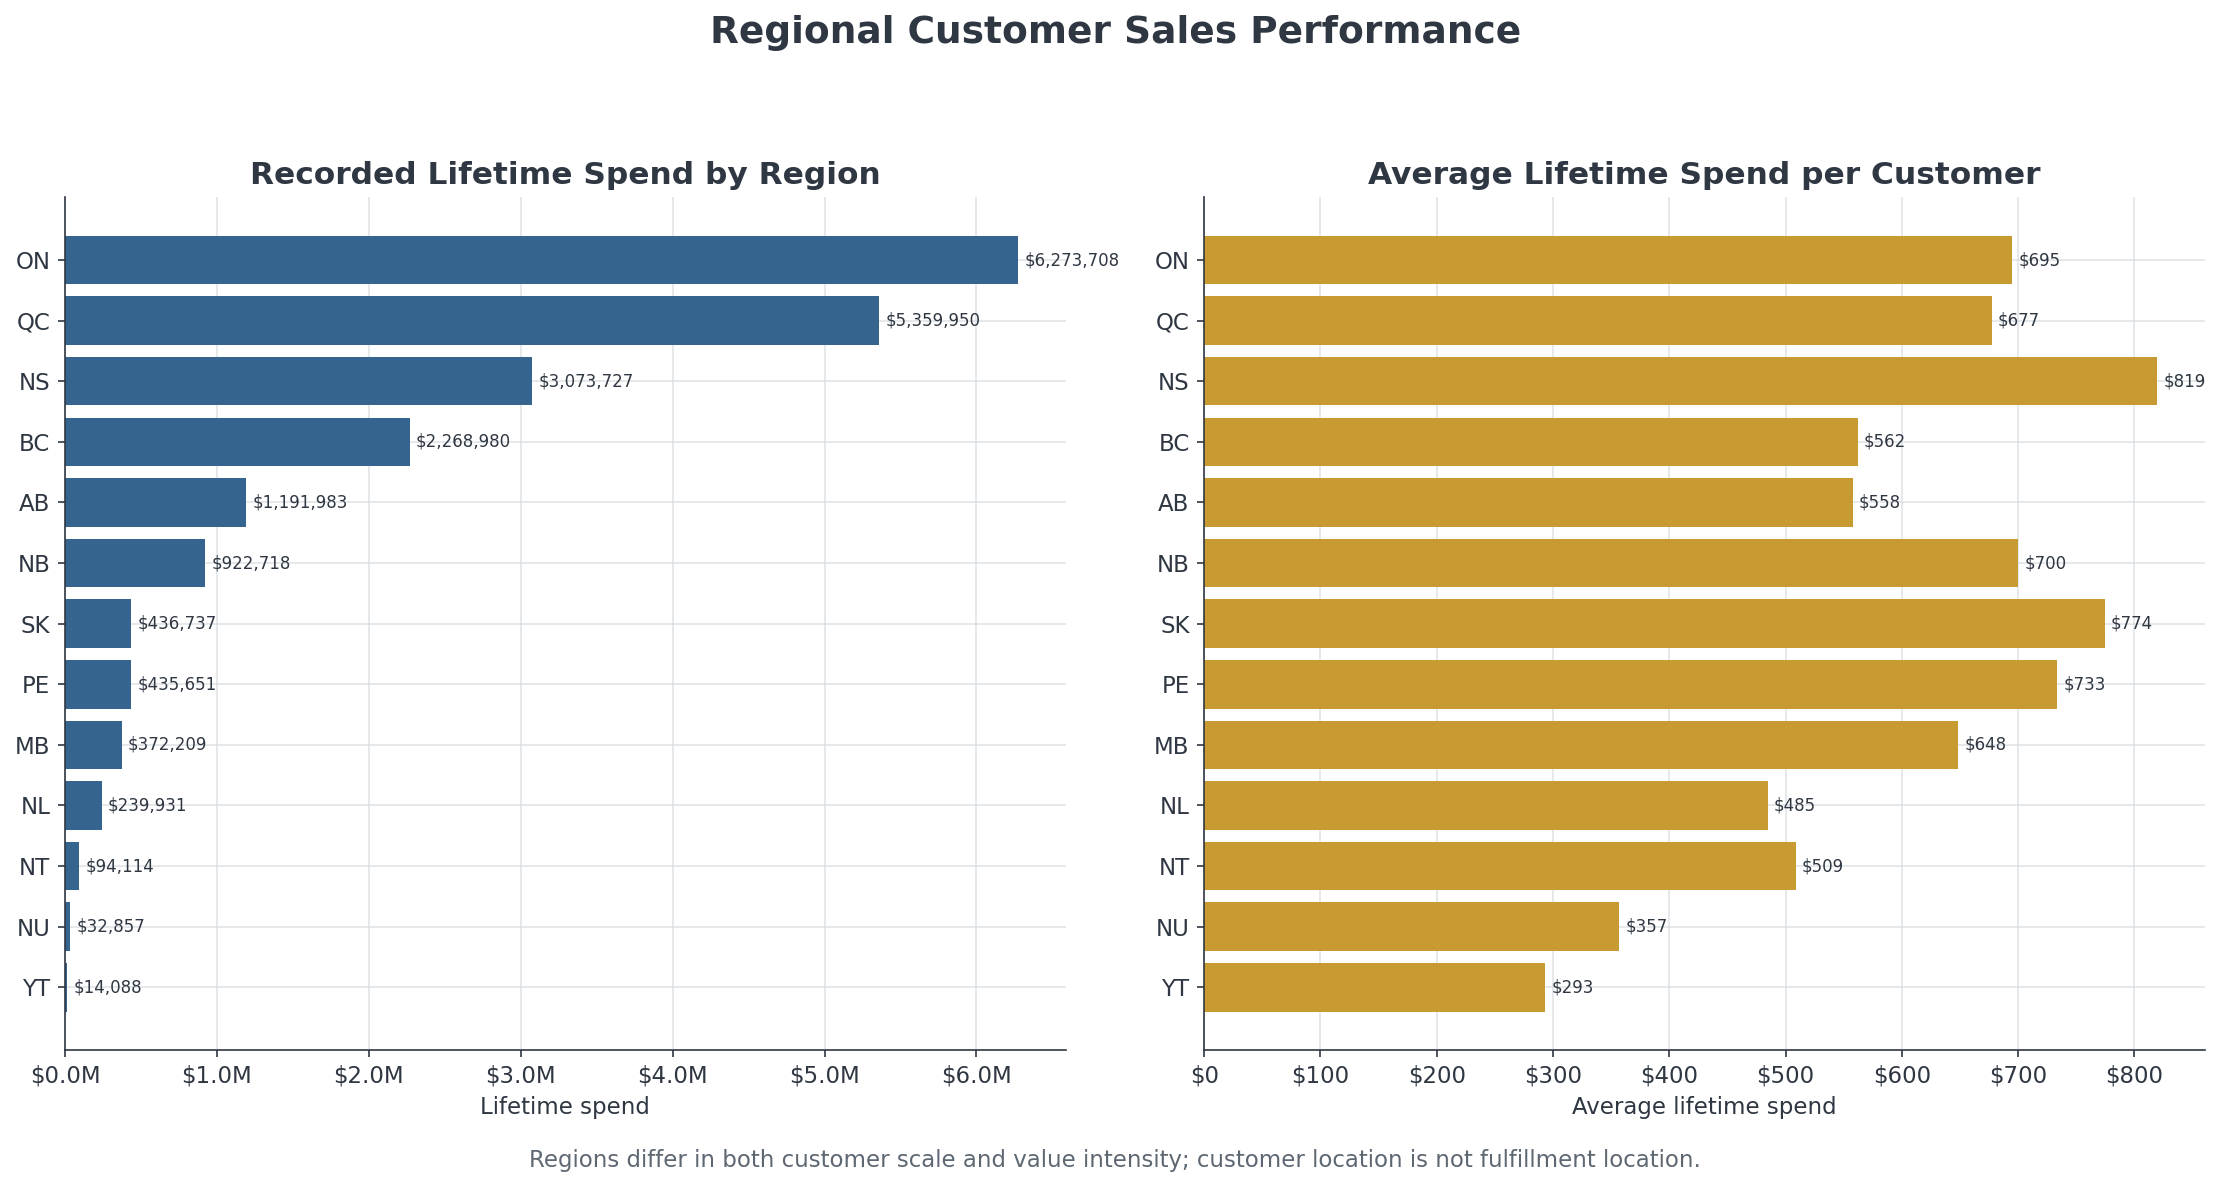

In [8]:
region_plot = regional_sales.sort_values("lifetime_spend", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

bars1 = axes[0].barh(region_plot["region"], region_plot["lifetime_spend"], color=COLORS["blue"])
axes[0].set_title("Recorded Lifetime Spend by Region")
axes[0].set_xlabel("Lifetime spend")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
axes[0].bar_label(bars1, labels=[money(v) for v in region_plot["lifetime_spend"]], padding=3, fontsize=8)
finish_axis(axes[0])

bars2 = axes[1].barh(region_plot["region"], region_plot["average_lifetime_spend"], color=COLORS["gold"])
axes[1].set_title("Average Lifetime Spend per Customer")
axes[1].set_xlabel("Average lifetime spend")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].bar_label(bars2, labels=[money(v) for v in region_plot["average_lifetime_spend"]], padding=3, fontsize=8)
finish_axis(axes[1])

fig.suptitle("Regional Customer Sales Performance", fontsize=18, fontweight="bold")
fig.text(0.5, 0.02, "Regions differ in both customer scale and value intensity; customer location is not fulfillment location.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
CHART_FILE = SALES_FOLDER / "03_regional_sales_performance.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 9. Examine order-frequency and customer-value relationships

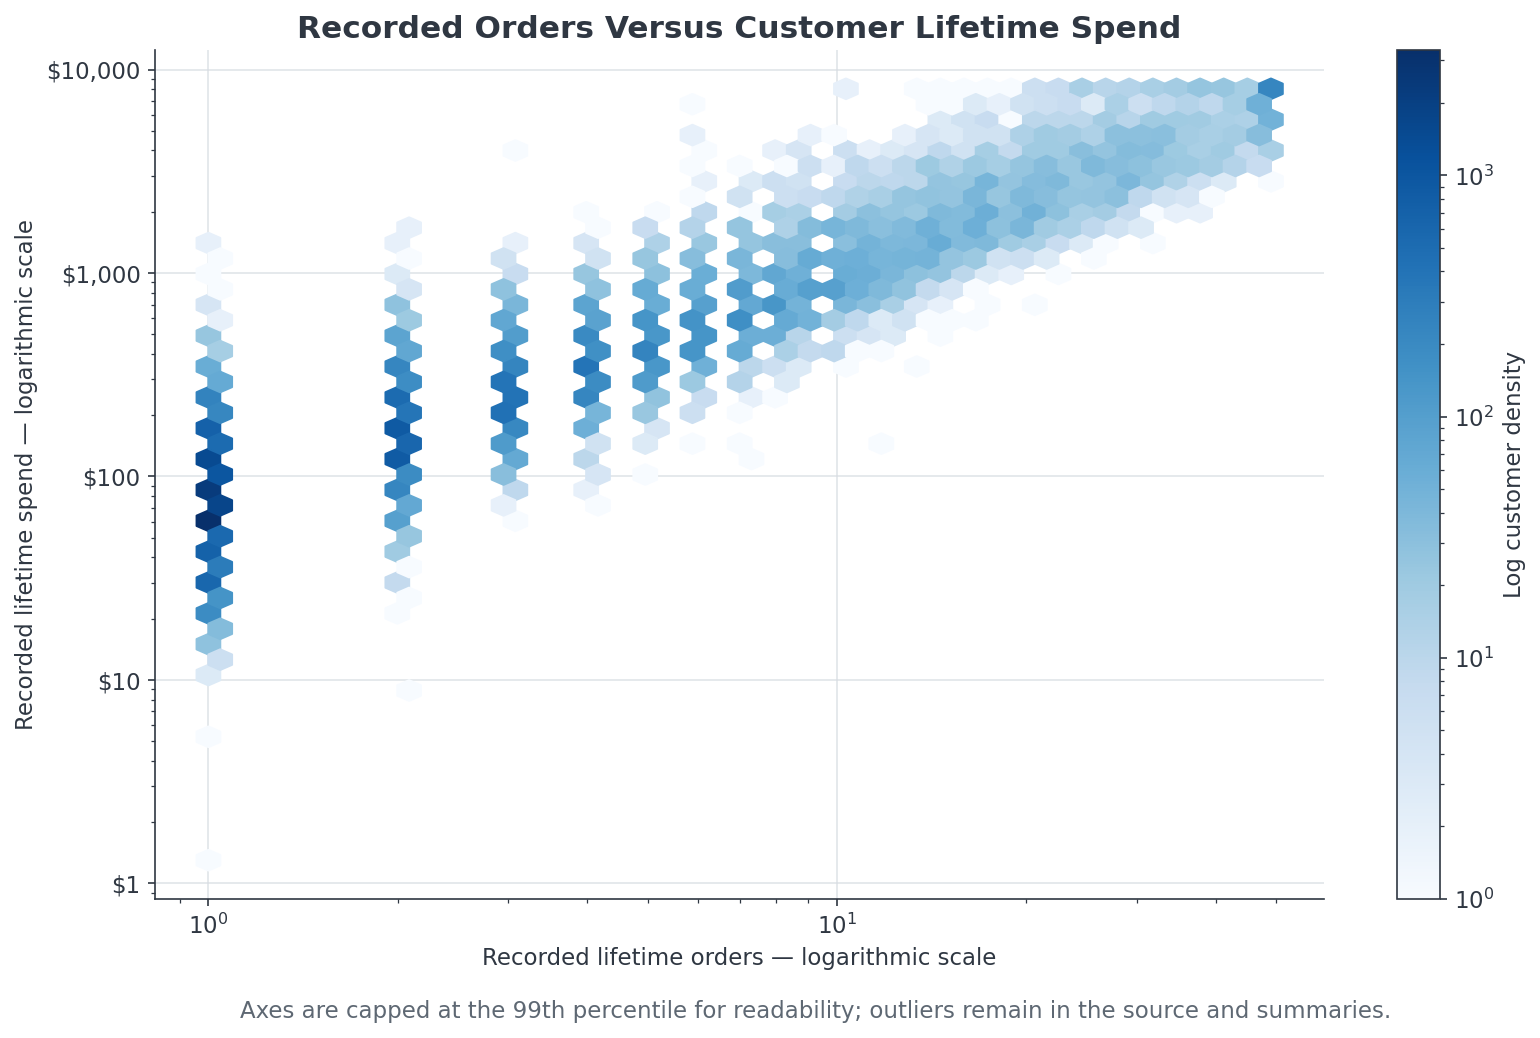

In [9]:
relationship_data = df.loc[df["total_spend"].gt(0), ["orders", "total_spend"]].copy()
relationship_data["orders"] = relationship_data["orders"].clip(upper=relationship_data["orders"].quantile(0.99))
relationship_data["total_spend"] = relationship_data["total_spend"].clip(upper=relationship_data["total_spend"].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 7))
hex_plot = ax.hexbin(
    relationship_data["orders"],
    relationship_data["total_spend"],
    xscale="log",
    yscale="log",
    gridsize=45,
    bins="log",
    mincnt=1,
    cmap="Blues",
)
ax.set_title("Recorded Orders Versus Customer Lifetime Spend")
ax.set_xlabel("Recorded lifetime orders — logarithmic scale")
ax.set_ylabel("Recorded lifetime spend — logarithmic scale")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
colorbar = fig.colorbar(hex_plot, ax=ax)
colorbar.set_label("Log customer density")
finish_axis(ax)
fig.text(0.5, 0.02, "Axes are capped at the 99th percentile for readability; outliers remain in the source and summaries.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = SALES_FOLDER / "04_orders_vs_lifetime_spend.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 10. Create next-order planning scenarios

In [10]:
active_customers = df.loc[df["days_since_last_active"].le(90)].copy()
active_customer_count = len(active_customers)
active_median_aov = float(active_customers["aov"].median())

scenario_rates = [0.25, 0.50, 0.75]
planning_scenarios = pd.DataFrame({
    "scenario": ["Conservative engagement", "Base engagement", "Upside engagement"],
    "active_customer_conversion": scenario_rates,
})
planning_scenarios["active_customers"] = active_customer_count
planning_scenarios["median_aov_assumption"] = active_median_aov
planning_scenarios["illustrative_next_order_revenue"] = (
    planning_scenarios["active_customer_conversion"]
    * active_customer_count
    * active_median_aov
)
planning_scenarios.to_csv(SALES_FOLDER / "next_order_revenue_scenarios.csv", index=False, encoding="utf-8-sig")
display(planning_scenarios)

               scenario  active_customer_conversion  active_customers  median_aov_assumption  illustrative_next_order_revenue
Conservative engagement                        0.25              7570                 101.65                       192,372.62
        Base engagement                        0.50              7570                 101.65                       384,745.25
      Upside engagement                        0.75              7570                 101.65                       577,117.88


### 11. Visualize the planning scenarios

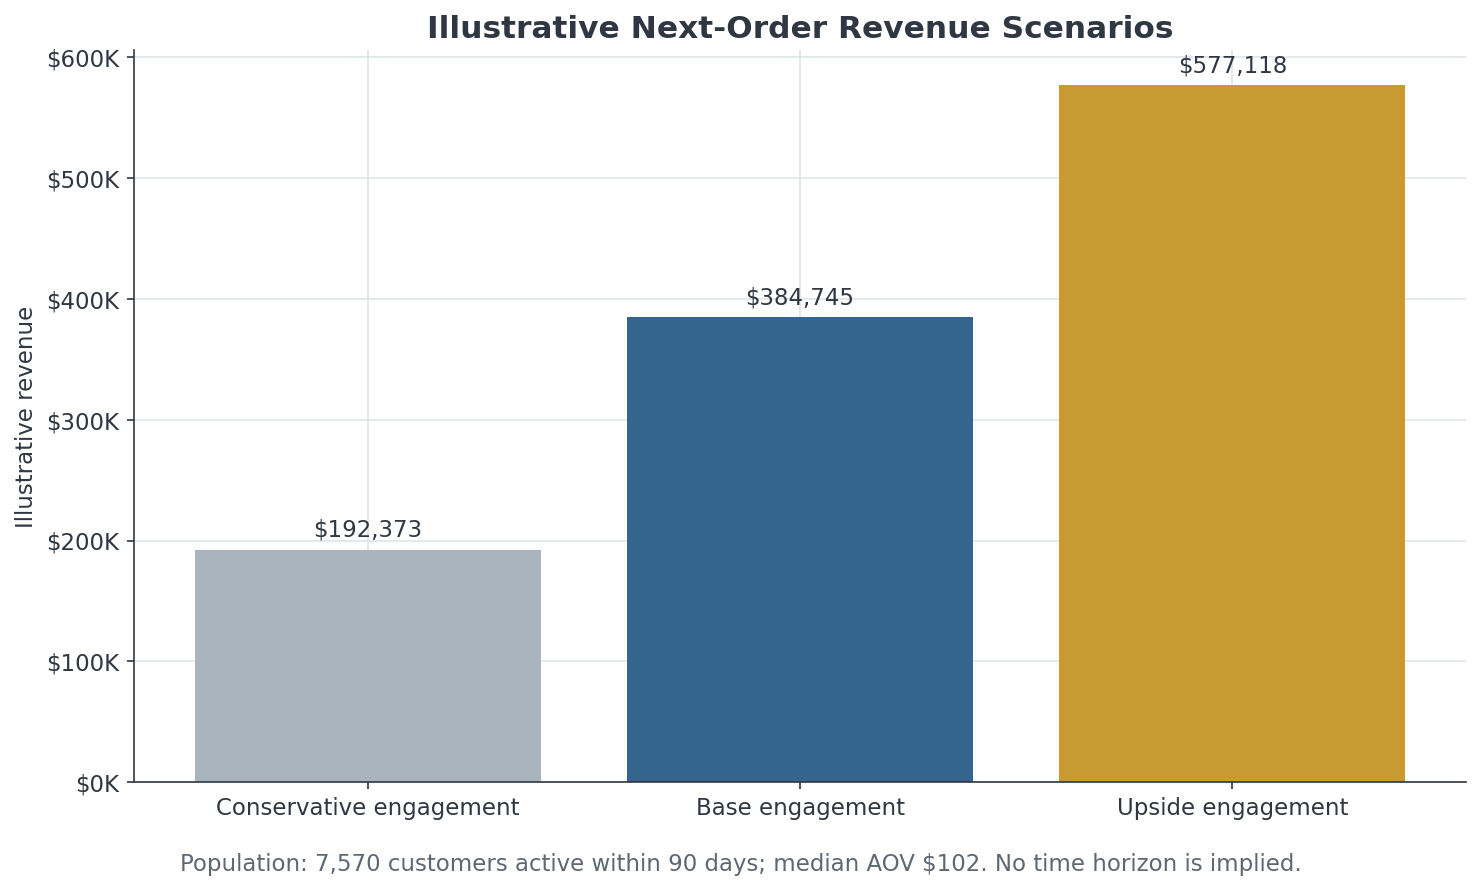

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(planning_scenarios["scenario"], planning_scenarios["illustrative_next_order_revenue"], color=[COLORS["grey"], COLORS["blue"], COLORS["gold"]])
ax.set_title("Illustrative Next-Order Revenue Scenarios")
ax.set_ylabel("Illustrative revenue")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
ax.bar_label(bars, labels=[money(v) for v in planning_scenarios["illustrative_next_order_revenue"]], padding=4)
finish_axis(ax)
fig.text(0.5, 0.02, f"Population: {active_customer_count:,} customers active within 90 days; median AOV {money(active_median_aov)}. No time horizon is implied.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.05, 1, 1])
CHART_FILE = SALES_FOLDER / "05_next_order_planning_scenarios.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Strategic recommendations

In [12]:
top_regions = regional_sales.head(3)
top_region_spend_share = top_regions["lifetime_spend"].sum() / total_lifetime_spend
repeat_spend_share = repeat_summary.loc[repeat_summary["is_repeat_customer"], "spend_share"].iloc[0]

sales_recommendations = pd.DataFrame([
    {
        "priority": 1,
        "recommendation": "Create a key-account retention motion for the top-value customer base",
        "evidence": f"Top 20% of customers contribute {top_20_spend_share:.1%} of recorded lifetime spend.",
        "next_action": "Assign service tiers and monitor 30/60/90-day inactivity for top accounts",
    },
    {
        "priority": 2,
        "recommendation": "Make repeat conversion the primary sales-growth KPI",
        "evidence": f"Repeat customers contribute {repeat_spend_share:.1%} of lifetime spend.",
        "next_action": "Track first-to-second purchase conversion by acquisition cohort",
    },
    {
        "priority": 3,
        "recommendation": "Prioritize regional execution where scale and value overlap",
        "evidence": f"{', '.join(top_regions['region'])} contribute {top_region_spend_share:.1%} of recorded lifetime spend.",
        "next_action": "Set regional targets using customers, repeat rate and weighted AOV—not revenue alone",
    },
    {
        "priority": 4,
        "recommendation": "Do not treat next-order scenarios as a formal sales forecast",
        "evidence": "The file has lifetime totals but no order-level transaction dates or seasonality.",
        "next_action": "Add order date, order value, product, status, discount and channel fields for weekly forecasting",
    },
])
sales_recommendations.to_csv(SALES_FOLDER / "sales_strategic_recommendations.csv", index=False, encoding="utf-8-sig")
display(sales_recommendations)

 priority                                                        recommendation                                                                          evidence                                                                                      next_action
        1 Create a key-account retention motion for the top-value customer base                 Top 20% of customers contribute 79.9% of recorded lifetime spend.                        Assign service tiers and monitor 30/60/90-day inactivity for top accounts
        2                   Make repeat conversion the primary sales-growth KPI                              Repeat customers contribute 93.8% of lifetime spend.                                  Track first-to-second purchase conversion by acquisition cohort
        3           Prioritize regional execution where scale and value overlap                           ON, QC, NS contribute 70.9% of recorded lifetime spend.             Set regional targets using customers, repeat rate

## Validation and limitations

In [13]:
assert total_orders == int(df["orders"].sum())
assert np.isclose(total_lifetime_spend, regional_sales["lifetime_spend"].sum() + df.loc[df["region"].isna(), "total_spend"].sum())
assert np.isclose(repeat_summary["lifetime_spend"].sum(), total_lifetime_spend)
assert planning_scenarios["illustrative_next_order_revenue"].is_monotonic_increasing

validation = pd.DataFrame({
    "check": ["Order reconciliation", "Regional sales reconciliation", "Repeat sales reconciliation", "Forecast limitation"],
    "result": ["Passed", "Passed", "Passed", "Formal time-series forecast requires order dates"],
})
display(validation)

                        check                                           result
         Order reconciliation                                           Passed
Regional sales reconciliation                                           Passed
  Repeat sales reconciliation                                           Passed
          Forecast limitation Formal time-series forecast requires order dates
